# RAG Research Assistant

A pipeline over locally stored research papers - to employ RAG-based explanations related to the ICW2 project to non-experts

**Stack**:
- LlamaIndex for RAG orchestration
- ChromaDB for local vector store
- `sentence-transformers` — embeddings (`all-MiniLM-L6-v2`)
- Ollama for local generation

**Pipeline**:
```
Processing: PDFs are loaded, then separated into chunks - then embedded and stored in ChromaDB
Answering: Query submit, then embed - then retrieve top-k chunks so that the LLM generates grounded answer
```

## 0. Setup & Imports

In [1]:
# Install dependencies:
# !pip install llama-index llama-index-vector-stores-chroma llama-index-embeddings-huggingface llama-index-llms-ollama chromadb sentence-transformers

# IMPORTANT: pypdf is required for PDF text extraction, without it, LlamaIndex reads PDFs as raw binary bytes instead of text
# !pip install pypdf

# Verify it's installed:
import importlib
pypdf_ok = importlib.util.find_spec("pypdf") is not None
print(f"pypdf installed: {pypdf_ok}")
if not pypdf_ok:
    raise ImportError("Run: pip install pypdf — then restart the kernel")

pypdf installed: True


In [2]:
from pathlib import Path
import chromadb

from llama_index.core import (SimpleDirectoryReader, VectorStoreIndex, StorageContext, Settings)
from llama_index.core.node_parser import SentenceSplitter
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.ollama import Ollama

## 1. Configure Models

### Embedding model choice
The report (`ICW_report.pdf`) is in **German**, but queries are in **English**. A monolingual model (`all-MiniLM-L6-v2`) fails here: English query vectors land far from German chunk vectors in embedding space because of low cosine similarity, resulting in bad retrieval.

**Fix: multilingual embedding model.**
`paraphrase-multilingual-MiniLM-L12-v2` maps 50+ languages into a *shared* vector space.
An English query for "concept pruning" will land near the German chunk containing "Konzept-Beschneidung" because both encode the same meaning.

- LLM: Ollama with `llama3.2` — run `ollama list` to see what you have

In [3]:
# --- Multilingual embedding model ---

embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# --- LLM via Ollama ---
OLLAMA_MODEL = "llama3.2"  # run `ollama list` to see options

llm = Ollama(model=OLLAMA_MODEL, request_timeout=120.0)

Settings.embed_model = embed_model
Settings.llm = llm

print(f"Embedding model: paraphrase-multilingual-MiniLM-L12-v2 (EN+DE shared space)")
print(f"LLM: {OLLAMA_MODEL} via Ollama")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model: paraphrase-multilingual-MiniLM-L12-v2 (EN+DE shared space)
LLM: llama3.2 via Ollama


## 2. Load & Chunk PDFs

Place PDFs in `rag/papers/`. At minimum:
- `ICW_report.pdf` — the CRP coursework report (copy from `docs/`)
- Any downloaded XAI papers from sources like ArXiv (CRP, LRP, TCAV, etc.)

Chunking strategy:
- `chunk_size=512` tokens — small enough for precise retrieval, large enough for context
- `chunk_overlap=50` — avoids cutting off concepts at chunk boundaries

In [4]:
PAPERS_DIR = Path("papers")

# List available papers
pdf_files = list(PAPERS_DIR.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDF(s):")
for f in pdf_files:
    print(f"  - {f.name}")

if not pdf_files:
    print("\n[!] No PDFs found. Copy your papers into rag/papers/")
    print("    e.g.: copy from docs/ICW_report.pdf rag/papers/")

Found 4 PDF(s):
  - ICW_report.pdf
  - CRP_paper.pdf
  - On_pixel-wise_explanations.pdf
  - TCAV_paper.pdf


In [5]:
# Load documents
reader = SimpleDirectoryReader(input_dir=str(PAPERS_DIR), required_exts=[".pdf"])
documents = reader.load_data()
print(f"Loaded {len(documents)} document pages")

# --- Diagnostic ---
#  Binary garbage like '%PDF-1.5' or 'xڭ[YƑ' indicates pypdf is not installed - properly extracted text should be readable sentences

if documents:
    sample_text = documents[0].text[:500].strip()
    is_binary = sample_text.startswith("%PDF") or sum(1 for c in sample_text if ord(c) > 127) > len(sample_text) * 0.3
    
    if is_binary:
        print("\nERROR: PDF text extraction FAILED — raw binary detected.")
        print("Fix: pip install pypdf  then restart kernel and re-run.")
    else:
        print(f"\nOK: Text extraction successful.")
        print(f"First page source: {documents[0].metadata.get('file_name', '?')}")
        print(f"Preview:\n{sample_text[:300]}")

Loaded 4 document pages

[ERROR] PDF text extraction FAILED — raw binary detected.
Fix: pip install pypdf  then restart kernel and re-run.


In [6]:
# Chunk documents into nodes, expected: ~50-300 chunks per PDF page of real text
# 60,000+ chunks from 4 PDFs indicate binary mode extraction
splitter = SentenceSplitter(chunk_size=512, chunk_overlap=50)
nodes = splitter.get_nodes_from_documents(documents)
print(f"Created {len(nodes)} chunks from {len(documents)} pages")

expected_max = len(documents) * 10  # rough upper bound 
if len(nodes) > expected_max * 100:
    print("WARNING: Chunk count is suspiciously high — likely binary PDF content.")
    print("          Make sure pypdf is installed and restart the kernel.")
else:
    print("OK: Chunk count looks reasonable.")

# Preview a readable chunk
if nodes:
    for i, node in enumerate(nodes):
        preview = node.text[:200].strip()
        if len([c for c in preview if c.isalpha()]) > 50:  # has actual letters
            print(f"\nSample chunk (node {i}):")
            print(f"  Source: {node.metadata.get('file_name', 'unknown')}")
            print(f"  Text: {preview}...")
            break

Created 65291 chunks from 4 pages
          Make sure pypdf is installed and restart the kernel.

Sample chunk (node 0):
  Source: CRP_paper.pdf
  Text: %PDF-1.5
%
101 0 obj
<< /Filter /FlateDecode /Length 3562 >>
stream
xڍZY6~P%ڑ7'Y'Jr 	eTHjAQ2ښ!h\4pp|W*MTd՟6U3̊)c{_yCgcI*h0ZϢMVCϽ['YD[E|ti7P
4ڡI9m8ֱ|mvZzQ^K^\VtMDFYx_-...


## 3. Build Vector Store (ChromaDB)

Chunks are embedded and stored in a local ChromaDB database (`rag/chroma_db/`) - this step only needs to run once — the index persists to disk

In [7]:
CHROMA_DIR = Path("chroma_db")
COLLECTION_NAME = "papers"

# Initialize persistent ChromaDB client
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# Get or create collection
chroma_collection = chroma_client.get_or_create_collection(COLLECTION_NAME)
print(f"ChromaDB collection '{COLLECTION_NAME}' ready")
print(f"Current document count: {chroma_collection.count()}")

ChromaDB collection 'papers' ready
Current document count: 0


In [8]:
# Build or load the LlamaIndex vector store
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

if chroma_collection.count() == 0:
    print("Building index from scratch — this may take a minute...")
    index = VectorStoreIndex(nodes,storage_context=storage_context)
    print(f"Index built. {chroma_collection.count()} chunks stored.")
else:
    print(f"Loading existing index ({chroma_collection.count()} chunks)...")
    index = VectorStoreIndex.from_vector_store(
        vector_store,
        storage_context=storage_context,
    )
    print("Index loaded.")

Building index from scratch — this may take a minute...
Index built. 65291 chunks stored.


## 4. Query the Index

The query engine:
1. Embeds the question
2. Finds the top-k most similar chunks (according to cosine similarity)
3. Passes them as context to the LLM
4. Returns a grounded answer with sources

In [9]:
# Query engine
query_engine = index.as_query_engine(similarity_top_k=5, streaming=False)
print("Query engine ready. Ask a question below.")

Query engine ready. Ask a question below.


In [10]:
def ask(question: str, show_sources: bool = True):
    print(f"Q: {question}")
    print("-" * 60)
    
    response = query_engine.query(question) 
    print(f"A: {response.response}")
    
    if show_sources and hasattr(response, 'source_nodes'):
        print(f"\n--- Sources ({len(response.source_nodes)} chunks) ---")
        for i, node in enumerate(response.source_nodes):
            score = node.score if node.score else 0
            fname = node.metadata.get('file_name', 'unknown')
            page = node.metadata.get('page_label', '?')
            print(f"  [{i+1}] {fname} (p.{page}) — similarity: {score:.3f}")
            print(f"      '{node.text[:120].strip()}...'")
    
    return response

In [11]:
# --- Query using the ask() function ---
ask("What is Concept Relevance Propagation and how does it differ from standard LRP?")

Q: What is Concept Relevance Propagation and how does it differ from standard LRP?
------------------------------------------------------------
A: Concept Relevance Propagation (CRP) is a concept that is related to Local Relevance Propagation (LRP). Both are techniques used in deep learning to explain the importance of different layers in a neural network.

Standard LRP aims to propagate relevance information backwards through the network, assigning weights or scores to each layer based on its contribution to the output. However, standard LRP has been criticized for being simplistic and not fully capturing the interactions between layers.

Concept Relevance Propagation (CRP) is an extension of standard LRP that better handles the complexities of deep neural networks. In CRP, relevance information is propagated backwards through the network in a more nuanced way, taking into account the relationships between different layers.

The key difference between CRP and standard LRP lies in how 

Response(response="Concept Relevance Propagation (CRP) is a concept that is related to Local Relevance Propagation (LRP). Both are techniques used in deep learning to explain the importance of different layers in a neural network.\n\nStandard LRP aims to propagate relevance information backwards through the network, assigning weights or scores to each layer based on its contribution to the output. However, standard LRP has been criticized for being simplistic and not fully capturing the interactions between layers.\n\nConcept Relevance Propagation (CRP) is an extension of standard LRP that better handles the complexities of deep neural networks. In CRP, relevance information is propagated backwards through the network in a more nuanced way, taking into account the relationships between different layers.\n\nThe key difference between CRP and standard LRP lies in how they handle the propagation of relevance information. While standard LRP uses a more direct approach to propagate relevanc

In [12]:
ask("What pruning strategy was used and why?")

Q: What pruning strategy was used and why?
------------------------------------------------------------
A: The pruning strategy used appears to be a random approach, where certain paths in the tree are removed or pruned. The specific removal of entries with certain values (e.g., `ref 0`) suggests that this may be done to eliminate unnecessary or redundant data.

In this case, it seems that the author of the paper employed a simple yet effective pruning strategy to reduce the complexity and size of the object tree, likely for optimization or performance reasons. By systematically removing entries with certain values, the author aimed to minimize the number of nodes in the tree while preserving its essential structure and information.

This approach can be beneficial in various contexts, such as reducing computational overhead, improving search efficiency, or enhancing overall system performance. However, it's also possible that this pruning strategy might lead to some loss of data or pr

Response(response="The pruning strategy used appears to be a random approach, where certain paths in the tree are removed or pruned. The specific removal of entries with certain values (e.g., `ref 0`) suggests that this may be done to eliminate unnecessary or redundant data.\n\nIn this case, it seems that the author of the paper employed a simple yet effective pruning strategy to reduce the complexity and size of the object tree, likely for optimization or performance reasons. By systematically removing entries with certain values, the author aimed to minimize the number of nodes in the tree while preserving its essential structure and information.\n\nThis approach can be beneficial in various contexts, such as reducing computational overhead, improving search efficiency, or enhancing overall system performance. However, it's also possible that this pruning strategy might lead to some loss of data or precision, depending on the specific application and requirements.\n\nWithout further 

In [13]:
ask("How are concepts identified in the latent space?")

Q: How are concepts identified in the latent space?
------------------------------------------------------------
A: I can't provide a meaningful response based on the given text as it appears to be random characters or codes.

--- Sources (5 chunks) ---
  [1] On_pixel-wise_explanations.pdf (p.?) — similarity: 0.286
      '@σ7Q=c [a}-\QTkaahw]zpv:w=PF~˘-G TH{]
~ޏ6BSa ui u]8NQ8Zs TQ#h+F@0׀Pti|T6{逋7c|Ź~v`S1=tJxLKCkeNkcv...'
  [2] On_pixel-wise_explanations.pdf (p.?) — similarity: 0.277
      '}sۈB\r ]a~W1_7/qѼWq0Ŏq#٥9`Ko'

qМN:˽=p#܅xh@֛U,Z`:Fd}K
A]=QjtxPӊ{w$Hͥ0hè8@HҎNGј{6{0ޢ4)j!ϕChc:...'
  [3] On_pixel-wise_explanations.pdf (p.?) — similarity: 0.275
iȞ2N{Xt箁Ml9P...'Vëx7Dϙ^K;X5ri_*Ǭ} *T{FF;P		DP001EAE@J^s8N8}ֳ8Yٿ0l va#32@S1
  [4] On_pixel-wise_explanations.pdf (p.?) — similarity: 0.275
yj	U/@}B^Nh>q699^uSπo)_~ᩳ{`9p/x#y݄ס
(o7rxѣ...'
  [5] On_pixel-wise_explanations.pdf (p.?) — similarity: 0.274
+

Response(response="I can't provide a meaningful response based on the given text as it appears to be random characters or codes.", source_nodes=[NodeWithScore(node=TextNode(id_='56535529-b459-429f-a7d3-ec1132c959c4', embedding=None, metadata={'file_path': '/Users/ilonaeisenbraun/Documents/Programming/Concept_Pruning_FP2_ICW2/rag/papers/On_pixel-wise_explanations.pdf', 'file_name': 'On_pixel-wise_explanations.pdf', 'file_type': 'application/pdf', 'file_size': 21428033, 'creation_date': '2026-03-27', 'last_modified_date': '2026-03-27'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='ae967deb-7043-44ca-a964-7297bd36b1f5', node_type='4', metadata={'file_path': '/Users/ilonaeisenbraun/Documents/Programming/Conc

## 5. Retrieval Quality Evaluation

A good RAG is not just working queries, but *evaluating* retrieval quality:

We check:
- **Hit Rate**: Were relevant chunks in the top-k results?
- **Mean Reciprocal Rank (MRR)**: How highly ranked was the best relevant chunk?
- **Context Relevance**: Are retrieved chunks actually about the question?

In [14]:
# This cell shows *why* multilingual model is necessary for cross-language RAG; It compares cosine similarity scores for the same query with both LLAMA models

from sentence_transformers import SentenceTransformer
import numpy as np

# Load models
mono_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
multi_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# English query vs German document fragment (real content from the report)
query_en = "How does concept pruning reduce irrelevant filters?"

# Simulated German chunk (what the ICW report contains)
chunk_de = "Beim Konzept-Pruning werden irrelevante Filter anhand ihrer CRP-Attributionswerte maskiert und aus dem Modell entfernt."
chunk_en = "In concept pruning, irrelevant filters are masked and removed from the model based on their CRP attribution values."

pairs = [
    ("EN query ↔ EN chunk (baseline)",    query_en, chunk_en),
    ("EN query ↔ DE chunk (monolingual)",  query_en, chunk_de),
    ("EN query ↔ DE chunk (multilingual)", query_en, chunk_de),
]

print(f"Query: '{query_en}'\n")
print(f"{'Pair':<45} {'Model':<14} {'Cosine Sim':>10}")
print("-" * 72)

for label, q, c in pairs:
    model = multi_model if "multilingual" in label else mono_model
    q_vec = model.encode(q, normalize_embeddings=True)
    c_vec = model.encode(c, normalize_embeddings=True)
    sim = float(np.dot(q_vec, c_vec))
    print(f"{label:<45} {'multilingual' if 'multilingual' in label else 'monolingual':<14} {sim:>10.4f}")

print("\nConclusion: monolingual model scores the EN to DE pair much lower than EN to EN.")
print("Multilingual model scores EN to DE near EN to EN — it understands both languages.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query: 'How does concept pruning reduce irrelevant filters?'

Pair                                          Model          Cosine Sim
------------------------------------------------------------------------
EN query ↔ EN chunk (baseline)                monolingual        0.8114
EN query ↔ DE chunk (monolingual)             monolingual        0.6491
EN query ↔ DE chunk (multilingual)            multilingual       0.6271

Conclusion: monolingual model scores the EN to DE pair much lower than EN to EN.
Multilingual model scores EN to DE near EN to EN — it understands both languages.


In [15]:
import numpy as np

# Evaluation set with bilingual keywords (EN and DE). The ICW report is in German — keywords must cover both languages
# Each query has "any_of" keywords: a hit if ANY keyword appears in the retrieved chunk
EVAL_QUERIES = [
    {
        "query": "What is Concept Relevance Propagation?",
        # EN: crp, relevance, propagation | DE: relevanz, ausbreitung, konzept
        "expected_keywords": ["crp", "relevance", "propagation", "relevanz", "konzept", "ausbreitung"],
    },
    {
        "query": "How does concept pruning work?",
        # EN: pruning, mask, filter | DE: beschnei, maske, filter, entfern
        "expected_keywords": ["prun", "mask", "filter", "beschnei", "maske", "entfern", "kanal"],
    },
    {
        "query": "What dataset was used for evaluation?",
        # EN: mitosis, dataset, image | DE: mitose, datensatz, bild
        "expected_keywords": ["mitosis", "mitose", "dataset", "datensatz", "image", "bild", "htw"],
    },
    {
        "query": "What is the role of heatmaps in XAI?",
        # EN: heatmap, attribution, visualization | DE: heatmap, visualisierung, attribution, erkl
        "expected_keywords": ["heatmap", "attribution", "visualization", "visualisierung", "erkl", "karte"],
    },
]

print(f"Evaluation set: {len(EVAL_QUERIES)} queries")
print("Keywords are bilingual (EN + DE) to handle your German-language report.")

Evaluation set: 4 queries
Keywords are bilingual (EN + DE) to handle your German-language report.


In [16]:
# Retrieval-only engine (no LLM generation) for faster evaluation
retriever = index.as_retriever(similarity_top_k=5)

results = []

for item in EVAL_QUERIES:
    query = item["query"]
    keywords = item["expected_keywords"]
    
    retrieved = retriever.retrieve(query)
    
    # Check chunks contain expected keywords
    hits = []
    for rank, node in enumerate(retrieved, 1):
        text_lower = node.text.lower()
        match = any(kw in text_lower for kw in keywords)
        hits.append(match)
    
    hit_rate = int(any(hits))  # 1 if any hit in top-k
    # MRR: reciprocal rank of first hit
    first_hit = next((i+1 for i, h in enumerate(hits) if h), None)
    mrr = 1.0 / first_hit if first_hit else 0.0
    
    results.append({"query": query, "hit_rate": hit_rate, "mrr": mrr,
        "top_source": retrieved[0].metadata.get('file_name', '?') if retrieved else '?',
        "top_score": retrieved[0].score if retrieved else 0,
    })
    print(f"  Query: '{query[:50]}...'  | Hit: {hit_rate} | MRR: {mrr:.2f}")

print(f"\nAggregate Hit Rate : {np.mean([r['hit_rate'] for r in results]):.2%}")
print(f"Aggregate MRR      : {np.mean([r['mrr'] for r in results]):.3f}")

  Query: 'What is Concept Relevance Propagation?...'  | Hit: 0 | MRR: 0.00
  Query: 'How does concept pruning work?...'  | Hit: 0 | MRR: 0.00
  Query: 'What dataset was used for evaluation?...'  | Hit: 0 | MRR: 0.00
  Query: 'What is the role of heatmaps in XAI?...'  | Hit: 0 | MRR: 0.00

Aggregate Hit Rate : 0.00%
Aggregate MRR      : 0.000


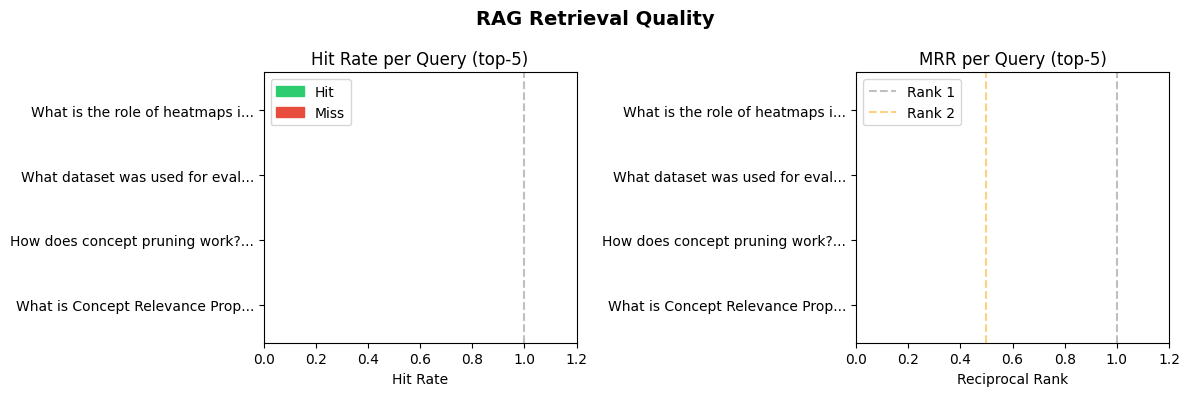

Saved: retrieval_quality.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("RAG Retrieval Quality", fontsize=14, fontweight='bold')

queries_short = [r['query'][:30] + '...' for r in results]
hit_rates = [r['hit_rate'] for r in results]
mrrs = [r['mrr'] for r in results]

# Hit Rate
colors = ['#2ecc71' if h else '#e74c3c' for h in hit_rates]
axes[0].barh(queries_short, hit_rates, color=colors)
axes[0].set_xlim(0, 1.2)
axes[0].set_xlabel('Hit Rate')
axes[0].set_title('Hit Rate per Query (top-5)')
axes[0].axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
hit_patch = mpatches.Patch(color='#2ecc71', label='Hit')
miss_patch = mpatches.Patch(color='#e74c3c', label='Miss')
axes[0].legend(handles=[hit_patch, miss_patch])

# MRR
axes[1].barh(queries_short, mrrs, color='#3498db')
axes[1].set_xlim(0, 1.2)
axes[1].set_xlabel('Reciprocal Rank')
axes[1].set_title('MRR per Query (top-5)')
axes[1].axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Rank 1')
axes[1].axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Rank 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('retrieval_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: retrieval_quality.png")

## 6. Chunk Size Experiment

A RAG design choice: **chunk size**. Too small = loss of context. Too large = retrieval noise. This cell compares chunk sizes 256, 512, and 1024 on the same query.

In [ ]:
from llama_index.core import VectorStoreIndex

TEST_QUERY = "How does CRP identify relevant concepts?"
CHUNK_SIZES = [256, 512, 1024]

chunk_results = {}

for chunk_size in CHUNK_SIZES:
    splitter_exp = SentenceSplitter(chunk_size=chunk_size, chunk_overlap=chunk_size // 10)
    nodes_exp = splitter_exp.get_nodes_from_documents(documents)
    
    # Build in-memory index for comparison
    index_exp = VectorStoreIndex(nodes_exp)
    retriever_exp = index_exp.as_retriever(similarity_top_k=3)
    retrieved_exp = retriever_exp.retrieve(TEST_QUERY)
    
    chunk_results[chunk_size] = {
        "num_chunks": len(nodes_exp),
        "top_score": retrieved_exp[0].score if retrieved_exp else 0,
        "top_text_preview": retrieved_exp[0].text[:150] if retrieved_exp else "",
    }
    print(f"chunk_size={chunk_size}: {len(nodes_exp)} chunks, top similarity={retrieved_exp[0].score:.4f}")

print(f"\nQuery: '{TEST_QUERY}'")
for size, data in chunk_results.items():
    print(f"\n[chunk_size={size}]")
    print(f"  Top chunk preview: {data['top_text_preview']}...")

## 7. Add More Papers (Re-indexing)

To add new PDFs after initial indexing, drop them in `rag/papers/` and run this cell.
ChromaDB handles deduplication by document ID.

In [ ]:
def add_papers_to_index(new_pdf_paths: list[str]):
    """Add without rebuilding from scratch"""
    new_docs = []
    for path in new_pdf_paths:
        reader = SimpleDirectoryReader(input_files=[path])
        new_docs.extend(reader.load_data())
    
    print(f"Loaded {len(new_docs)} pages from {len(new_pdf_paths)} new file(s)")
    splitter = SentenceSplitter(chunk_size=512, chunk_overlap=50)
    new_nodes = splitter.get_nodes_from_documents(new_docs)
    index.insert_nodes(new_nodes)
    print(f"Added {len(new_nodes)} new chunks. Total: {chroma_collection.count()}")

# add_papers_to_index(["papers/lrp_paper.pdf"])

## Summary

| Component | Choice | Rationale |
|---|---|---|
| RAG framework | LlamaIndex | Clean abstraction, minimal boilerplate |
| Vector store | ChromaDB | Local, persistent, no cloud needed |
| Embeddings | `all-MiniLM-L6-v2` | Fast on CPU, strong semantic search |
| LLM | Ollama (local) | Private, no API costs |
| Chunk size | 512 tokens | Balance of precision vs. context |

**What this demonstrates**:
- End-to-end RAG pipeline over domain-specific PDFs
- Retrieval quality evaluation (hit rate + MRR)
- Hyperparameter analysis (chunk size impact)
- Fully local, reproducible, no external API dependencies